# Zusammenfassung - Machine Learning Pipeline

<div style="padding: 5px; border: 5px solid #a10000ff;">

**Hinweis:** Die Codezellen in diesem Notebook sind **bereits fertig programmiert**. 
Sie können alle Zellen nacheinander ausführen und die vollständige Pipeline durchlaufen. 
Zwischen den einzelnen Abschnitten finden Sie **Verständnisfragen**, die Ihr Wissen aus dem Kurs prüfen. 
Beantworten Sie diese Fragen in den dafür vorgesehenen Stellen (`>`).

</div>

## Machine Learning Pipeline

Ziel dieses Notebooks ist es, einen Überblick über die Schritte einer typischen Machine Learning Pipeline zu geben. Dabei werden wir ein neuronales Netzwerk trainieren, um vorherzusagen, ob jemand von einer Herzerkrankung betroffen ist oder nicht. Die einzelnen Schritte in diesem Prozess werden auch unter dem Begriff "Machine Learning Pipeline" zusammengefasst. Diese Pipeline besteht aus mehreren Schritten, die nacheinander durchlaufen werden, um ein funktionierendes Machine Learning Modell zu erstellen. Die Schritte sind:

1. **Datenbeschaffung**: Sammeln von Daten aus verschiedenen Quellen. *Hier wird das Dataset einfach geladen.*
2. **Datenvorverarbeitung**: Bereinigung und Vorbereitung der Daten für die Analyse.
3. **Feature Engineering**: Auswahl und Transformation von Merkmalen, um die Leistung des Modells zu verbessern.
4. **Modellauswahl**: Auswahl eines geeigneten Algorithmus für die Vorhersage.
5. **Modelltraining**: Trainieren des Modells mit den vorbereiteten Daten.
6. **Modellbewertung**: Bewertung der Leistung des Modells anhand von Metriken.
7. **Modelloptimierung**: Feinabstimmung der Hyperparameter, um die Leistung zu verbessern.
8. **Modellbereitstellung**: Implementierung des Modells in einer Produktionsumgebung. *(Wird hier nicht behandelt.)* 

## Dataset - Heart Disease Prediction

In diesem Notebook nutzen wir das "Heart Disease Prediction Dataset", um die Schritte der Machine Learning Pipeline zu demonstrieren. Das Ziel ist es, vorherzusagen, ob eine Person an Herzkrankheiten leidet oder nicht, basierend auf verschiedenen Merkmalen wie Alter, Geschlecht, Blutdruck, Cholesterinwerte und mehr.

Das Dataset beinhaltet 11 Features:

1. **Age**: Alter der Person
2. **Sex**: Geschlecht (M = männlich, F = weiblich)
3. **ChestPainType**: Brustschmerztyp (TA: Typical Angina, ATA: Atypical Angina, NAP: Non-Anginal Pain, ASY: Asymptomatic)
4. **RestingBP**: Ruheblutdruck
5. **Cholesterol**: Cholesterinwert
6. **FastingBS**: Nüchternblutzucker (1 = > 120 mg/dl, 0 = <= 120 mg/dl)
7. **RestingECG**: Ruhe-EKG-Ergebnisse (Normal, ST-T wave Anomalie, Left ventricular hypertrophy)
8. **MaxHR**: Maximale Herzfrequenz
9. **ExerciseAngina**: Angina während des Trainings (Y = Ja, N = Nein)
10. **Oldpeak**: Messwert während dem Belastungstest, Stärke der ST-Depression
11. **ST_Slope**: Messwert während dem Belastungstest, Steigung des ST-Segments (Up, Flat, Down)

Das Target ist die Spalte **HeartDisease**, die angibt, ob die Person an Herzkrankheiten leidet (1) oder nicht (0).

*Quelle: [Kaggle - Heart Disease Prediction Dataset](https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction)*

---

Als nächstes beginnen wir mit dem Laden des Datasets, um die Datenbeschaffung abzuschliessen, da wir hier mit einem bereits vorhandenen Dataset arbeiten. In einem realen Szenario könnte die Datenbeschaffung das Sammeln von Daten aus verschiedenen Quellen, wie z.B. Datenbanken oder Webseiten, beinhalten.

---
## 1. Datenbeschaffung

Der erste Schritt jeder Machine Learning Pipeline ist die **Datenbeschaffung**. Ohne Daten können wir kein Modell trainieren. In der Praxis können Daten zum Beispiel aus Datenbanken, APIs, Sensoren, Umfragen oder öffentlichen Datasets. Hier laden wir ein bereits vorhandenes CSV-File.

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("datasets/heart.csv")
print(f"Dataset geladen: {df.shape[0]} Zeilen, {df.shape[1]} Spalten")
df.head(10)

Dataset geladen: 918 Zeilen, 12 Spalten


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
5,39,M,NAP,120,339,0,Normal,170,N,0.0,Up,0
6,45,F,ATA,130,237,0,Normal,170,N,0.0,Up,0
7,54,M,ATA,110,208,0,Normal,142,N,0.0,Up,0
8,37,M,ASY,140,207,0,Normal,130,Y,1.5,Flat,1
9,48,F,ATA,120,284,0,Normal,120,N,0.0,Up,0


Wir haben das Dataset erfolgreich geladen. Es enthält 918 Patientendaten mit 11 Features und einer Zielvariable (HeartDisease). Bevor wir mit dem Modelltraining beginnen können, müssen wir die Daten zunächst genauer untersuchen und aufbereiten. Denn: **Ein Modell ist nur so gut wie die Daten, mit denen es trainiert wird.**

---

## 2. Datenqualität prüfen

Bevor wir die Daten in ein Modell geben, müssen wir ihre **Qualität** überprüfen. Fehlerhafte, fehlende oder inkonsistente Daten können die Leistung eines Modells enorm verschlechtern oder zu falschen Ergebnissen führen. Wir prüfen deshalb:

- **Fehlende Werte (Missing Values):** Gibt es Lücken in den Daten?
- **Ausreisser (Outliers):** Gibt es Werte, die ungewöhnlich weit vom Rest entfernt liegen?
- **Falsche / unrealistische Werte:** Gibt es Werte, die medizinisch keinen Sinn ergeben?

### 2.1 Fehlende Werte

In [3]:
# Fehlende Werte pro Spalte zaehlen
print("Fehlende Werte pro Spalte:")
print(df.isnull().sum())
print(f"\nGesamtanzahl fehlender Werte: {df.isnull().sum().sum()}")

Fehlende Werte pro Spalte:
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

Gesamtanzahl fehlender Werte: 0


Es gibt keine fehlenden Werte (NaN) im Dataset. Das ist ein gutes Zeichen. In der Praxis ist es jedoch häufig der Fall, dass Daten Lücken aufweisen. In solchen Fällen muss man entscheiden, ob man die betroffenen Zeilen entfernt oder die Werte z.B. durch den Mittelwert oder Median ersetzt.

### 2.2 Unrealistische Werte

Auch wenn keine Werte fehlen, können Daten trotzdem fehlerhaft sein. Ein Cholesterinwert von 0 ist medizinisch nicht möglich - das deutet auf fehlende oder fehlerhafte Messungen hin. Gleiches gilt für einen Ruheblutdruck von 0.
In der Praxis würden nicht Sie als Data-Scientist\*in diese Werte einfach entfernen, sondern mit Ärzt\*innen sprechen, um herauszufinden, ob es sich um falsche Werte handelt

In [4]:
# Grundlegende Statistiken anzeigen
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [5]:
# Unrealistische Null-Werte identifizieren
print(f"Anzahl Zeilen mit Cholesterol == 0: {(df['Cholesterol'] == 0).sum()}")
print(f"Anzahl Zeilen mit RestingBP == 0:   {(df['RestingBP'] == 0).sum()}")

Anzahl Zeilen mit Cholesterol == 0: 172
Anzahl Zeilen mit RestingBP == 0:   1


In [6]:
# Null-Werte durch den Median der jeweiligen Spalte ersetzen
# Der Median ist robuster gegenueber Ausreissern als der Mittelwert
cholesterol_median = df.loc[df['Cholesterol'] > 0, 'Cholesterol'].median()
restingbp_median = df.loc[df['RestingBP'] > 0, 'RestingBP'].median()

df.loc[df['Cholesterol'] == 0, 'Cholesterol'] = cholesterol_median
df.loc[df['RestingBP'] == 0, 'RestingBP'] = restingbp_median

print(f"Cholesterol-Median (ohne Nullen): {cholesterol_median}")
print(f"RestingBP-Median (ohne Nullen):   {restingbp_median}")
print(f"\nNach Bereinigung - Cholesterol == 0: {(df['Cholesterol'] == 0).sum()}")
print(f"Nach Bereinigung - RestingBP == 0:   {(df['RestingBP'] == 0).sum()}")

Cholesterol-Median (ohne Nullen): 237.0
RestingBP-Median (ohne Nullen):   130.0

Nach Bereinigung - Cholesterol == 0: 0
Nach Bereinigung - RestingBP == 0:   0


### 2.3 Ausreisser

Ausreisser sind Datenpunkte, die stark vom Rest abweichen. Sie können auf Messfehler oder tatsächlich seltene Fälle hindeuten. Wir visualisieren die numerischen Features mit Boxplots, um Ausreisser zu erkennen.

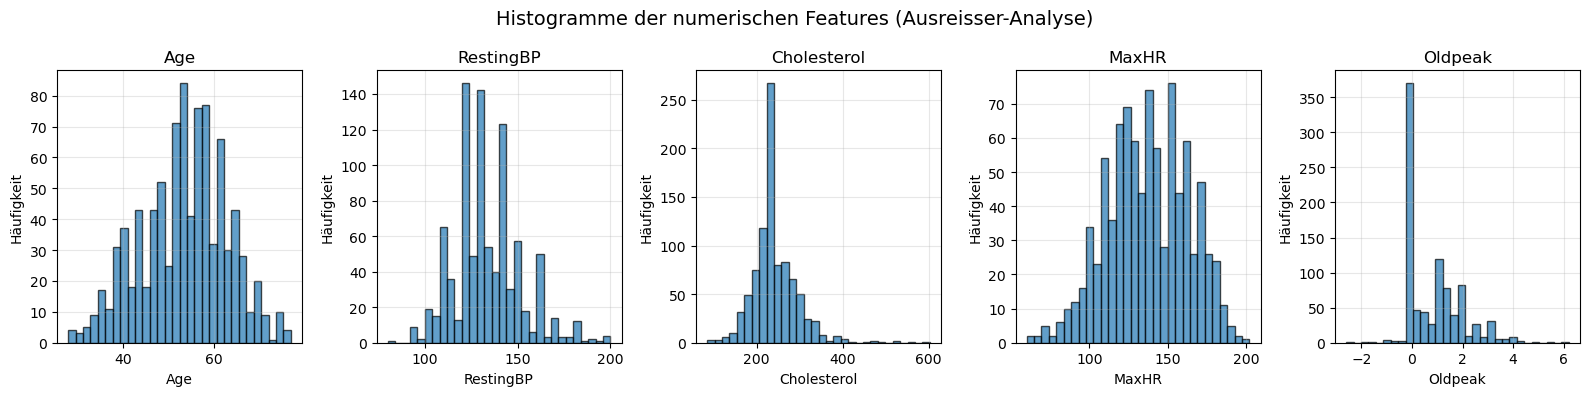

In [31]:
# Histogramme fuer numerische Spalten um Ausreisser zu erkennen
numerische_spalten = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

fig, axes = plt.subplots(1, len(numerische_spalten), figsize=(16, 4))
for i, col in enumerate(numerische_spalten):
    axes[i].hist(df[col], bins=30, edgecolor='black', alpha=0.7)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Häufigkeit')
    axes[i].set_title(col)
    axes[i].grid(True, alpha=0.3)
plt.suptitle("Histogramme der numerischen Features (Ausreisser-Analyse)", fontsize=14)
plt.tight_layout()
plt.show()

Es gibt einige Ausreisser, insbesondere beim Cholesterinwert (Werte über 500). In diesem Notebook belassen wir die Ausreisser im Dataset, da wir keine weiteren medizinischen Informationen haben. In anderen Projekten müsste man hier eine detailliertere Analyse durchführen und Fachpersonen konsultieren.

Die Datenqualitätsprüfung ist abgeschlossen. Wir haben fehlende Werte geprüft, unrealistische Null-Werte bereinigt und Ausreisser identifiziert. Als nächstes müssen wir die Daten so transformieren, dass unser neuronales Netzwerk damit arbeiten kann.

### Verständnisfragen: Datenqualität

**Frage A:** Warum haben wir den Median und nicht den Mittelwert verwendet, um die fehlerhaften Cholesterinwerte zu ersetzen?
>

**Frage B:** Nennen Sie zwei mögliche Strategien, um mit fehlenden Werten (NaN) in einem Dataset umzugehen.
>

---
## 3. Datenvorverarbeitung (Feature Engineering)

Neuronale Netzwerke können nur mit **numerischen Daten** arbeiten. Unser Dataset enthält jedoch kategoriale Spalten wie `Sex`, `ChestPainType`, `RestingECG`, `ExerciseAngina` und `ST_Slope`. Diese müssen in Zahlen umgewandelt werden. Dafür gibt es zwei gängige Verfahren:

- **Ordinal-Encoding:** Kategorien werden durch Zahlen ersetzt (z.B. "M" → 1, "F" → 0). Dies ist geeignet, wenn die Kategorien eine natürliche Reihenfolge haben oder nur zwei Ausprägungen existieren.
- **One-Hot-Encoding:** Jede Kategorie wird zu einer eigenen Feature-Spalte (0 oder 1). Dies ist geeignet, wenn es keine natürliche Reihenfolge gibt und mehr als zwei Ausprägungen existieren.

Ausserdem müssen wir die numerischen Werte **normalisieren**, damit Features mit grossen Wertebereichen (z.B. Cholesterin: 100-600) das Training nicht dominieren.

### 3.1 Kategoriale Variablen kodieren

In [8]:
# Vor der Transformation: Ueberblick ueber kategoriale Spalten
kategoriale_spalten = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
for col in kategoriale_spalten:
    print(f"{col}: {df[col].unique()}")

Sex: ['M' 'F']
ChestPainType: ['ATA' 'NAP' 'ASY' 'TA']
RestingECG: ['Normal' 'ST' 'LVH']
ExerciseAngina: ['N' 'Y']
ST_Slope: ['Up' 'Flat' 'Down']


In [9]:
# Ordinal-Encoding fuer binaere Spalten (nur zwei Auspraegungen)
df['Sex'] = df['Sex'].map({'M': 1, 'F': 0})
df['ExerciseAngina'] = df['ExerciseAngina'].map({'Y': 1, 'N': 0})

print("Ordinal-Encoding angewendet:")
print(f"  Sex:            {df['Sex'].unique()}")
print(f"  ExerciseAngina: {df['ExerciseAngina'].unique()}")

Ordinal-Encoding angewendet:
  Sex:            [1 0]
  ExerciseAngina: [0 1]


In [10]:
# One-Hot-Encoding fuer Spalten mit mehr als zwei Auspraegungen
df = pd.get_dummies(df, columns=['ChestPainType', 'RestingECG', 'ST_Slope'], dtype=int)

print(f"Neue Spaltenanzahl nach One-Hot-Encoding: {df.shape[1]}")
print(f"\nAlle Spalten:")
print(df.columns.tolist())

Neue Spaltenanzahl nach One-Hot-Encoding: 19

Alle Spalten:
['Age', 'Sex', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'HeartDisease', 'ChestPainType_ASY', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_LVH', 'RestingECG_Normal', 'RestingECG_ST', 'ST_Slope_Down', 'ST_Slope_Flat', 'ST_Slope_Up']


In [11]:
# Ergebnis betrachten
df.head()

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40,1,140,289,0,172,0,0.0,0,0,1,0,0,0,1,0,0,0,1
1,49,0,160,180,0,156,0,1.0,1,0,0,1,0,0,1,0,0,1,0
2,37,1,130,283,0,98,0,0.0,0,0,1,0,0,0,0,1,0,0,1
3,48,0,138,214,0,108,1,1.5,1,1,0,0,0,0,1,0,0,1,0
4,54,1,150,195,0,122,0,0.0,0,0,0,1,0,0,1,0,0,0,1


### 3.2 Normalisierung (Min-Max-Scaling)

Wir normalisieren alle numerischen Features auf den Bereich [0, 1]. Dadurch haben alle Features denselben Wertebereich und kein einzelnes Feature dominiert das Training aufgrund seiner Grössenordnung.

Die Formel für die Min-Max-Normalisierung lautet:

$$x_{\text{norm}} = \frac{x - x_{\min}}{x_{\max} - x_{\min}}$$

In [34]:
# Features und Target trennen
X = df.drop('HeartDisease', axis=1)
y = df['HeartDisease']

# Nur die urspruenglich numerischen Spalten normalisieren
# (One-Hot-Encoded Spalten sind bereits 0/1)
spalten_zum_normalisieren = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

for col in spalten_zum_normalisieren:
    x_min = X[col].min()
    x_max = X[col].max()
    X[col] = (X[col] - x_min) / (x_max - x_min)

print("Wertebereiche nach Normalisierung:")
for col in spalten_zum_normalisieren:
    print(f"  {col}: [{X[col].min():.2f}, {X[col].max():.2f}]")

Wertebereiche nach Normalisierung:
  Age: [0.00, 1.00]
  RestingBP: [0.00, 1.00]
  Cholesterol: [0.00, 1.00]
  MaxHR: [0.00, 1.00]
  Oldpeak: [0.00, 1.00]


Die Daten sind nun komplett vorbereitet: Kategoriale Variablen wurden kodiert und numerische Werte normalisiert. Alle Features liegen jetzt in einem einheitlichen numerischen Format vor, das von unserem neuronalen Netzwerk verarbeitet werden kann.

Im nächsten Schritt teilen wir die Daten in Training, Validation und Test auf.

### Verständnisfragen: Datenvorverarbeitung

**Frage A:** Was könnte passieren, wenn wir die numerischen Features *nicht* normalisieren würden? Welchen Einfluss hat dies auch auf die Trainingsgeschwindigkeit?
>

**Frage B:** Durch das One-Hot-Encoding hat sich die Spaltenanzahl verändert. Erklären Sie, warum aus der Spalte `ChestPainType` (mit 4 Kategorien) genau 4 neue Spalten entstanden sind.
> 


---
## 4. Datenaufteilung (Train / Validation / Test)

Um die Leistung unseres Modells objektiv bewerten zu können, teilen wir die Daten in drei Teile auf:

- **Trainingsdaten (70%):** Das Modell lernt aus diesen Daten.
- **Validierungsdaten (15%):** Werden während des Trainings genutzt, um Overfitting zu erkennen.
- **Testdaten (15%):** Werden erst ganz am Schluss verwendet, um die finale Leistung zu messen.

Diese Aufteilung stellt sicher, dass wir die Performance des Modells auf **noch nie gesehenen Daten** bewerten können.

Mit dem Parameter `stratify=y` stellen wir sicher, dass die Verteilung des Targets (HeartDisease) in allen drei Datensätzen praktisch gleich ist (z.B. 30% Disease, 70% No Disease in Train, Test und Val.). Das ist besonders wichtig, wenn die Klassen unausgeglichen sind.

In [13]:
# Zuerst: Train+Val (85%) vs. Test (15%)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

# Dann: Train (70% gesamt) vs. Val (15% gesamt)
# 15/85 ≈ 0.176 -> damit erhalten wir ca. 15% Validation vom Gesamtdatensatz
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.176, random_state=42, stratify=y_train_val
)

print(f"Trainingsdaten:     {X_train.shape[0]} Samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Validierungsdaten:  {X_val.shape[0]} Samples ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"Testdaten:          {X_test.shape[0]} Samples ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"\nGesamt:             {X_train.shape[0] + X_val.shape[0] + X_test.shape[0]} Samples")

Trainingsdaten:     642 Samples (69.9%)
Validierungsdaten:  138 Samples (15.0%)
Testdaten:          138 Samples (15.0%)

Gesamt:             918 Samples


In [14]:
# Verteilung der Klassen pruefen (stratified split)
print("Klassenverteilung (HeartDisease):")
print(f"  Training:    {y_train.value_counts().to_dict()}")
print(f"  Validation:  {y_val.value_counts().to_dict()}")
print(f"  Test:        {y_test.value_counts().to_dict()}")

Klassenverteilung (HeartDisease):
  Training:    {1: 356, 0: 286}
  Validation:  {1: 76, 0: 62}
  Test:        {1: 76, 0: 62}


In [15]:
# Daten in PyTorch-Tensoren umwandeln
X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1)

X_val_tensor = torch.tensor(X_val.values, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32).unsqueeze(1)

X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).unsqueeze(1)

# DataLoader erstellen
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Anzahl Features: {X_train_tensor.shape[1]}")
print(f"Train-Batches:   {len(train_loader)}")
print(f"Val-Batches:     {len(val_loader)}")
print(f"Test-Batches:    {len(test_loader)}")

Anzahl Features: 18
Train-Batches:   21
Val-Batches:     5
Test-Batches:    5


Die Daten sind nun in drei Teile aufgeteilt, in PyTorch-Tensoren umgewandelt und in DataLoader verpackt. Die DataLoader ermöglichen es uns, die Daten in Batches zu laden und effizient durch das Netzwerk zu leiten.

Im nächsten Schritt definieren wir die Architektur unseres neuronalen Netzwerks.

### Verständnisfragen: Datenaufteilung

**Frage A:** Warum teilen wir die Daten in **drei** Teile (Train/Validation/Test) und nicht nur in zwei (Train/Test)?
> 

**Frage B:** Was bedeutet der Parameter `stratify=y` bei `train_test_split`? Warum ist das bei unserem Dataset wichtig?
> 

**Frage C:** Was ist ein "Mini-Batch" und warum verwenden wir eine `batch_size` von 32 statt alle Daten auf einmal durch das Netzwerk vorhersagen zu lassen und so zu trainieren?
> 

---
## 5. Modellarchitektur definieren

Nun definieren wir ein kleines, vollständig verbundenes neuronales Netzwerk (Fully Connected Neural Network / Multi-Layer Perceptron). Das Netzwerk besteht aus:

- **Input-Layer:** Nimmt unsere Features entgegen.
- **Hidden Layers:** Zwei versteckte Schichten, die nicht-lineare Zusammenhänge in den Daten lernen.
- **Output-Layer:** Gibt einen einzelnen Wert aus (Wahrscheinlichkeit für Herzerkrankung).

Als Aktivierungsfunktion verwenden wir **ReLU** in den Hidden Layers und **Sigmoid** im Output-Layer. Die Sigmoid Aktivierungsfunktion erzeugt Werte zwischen 0 und 1. Der Output kann somit als Wahrscheinlichkeit interpretiert werden, dass eine Person an Herzkrankheiten leidet (Wert zwischen 0 und 1).

In [16]:
class HeartDiseaseNet(nn.Module):
    def __init__(self, input_size, hidden1, hidden2):
        super(HeartDiseaseNet, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, hidden1),
            nn.ReLU(),
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Linear(hidden2, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.network(x)


# Modell erstellen
input_size = X_train_tensor.shape[1]
model = HeartDiseaseNet(input_size=input_size, hidden1=64, hidden2=32)

print(model)
print(f"\nAnzahl trainierbarer Parameter: {sum(p.numel() for p in model.parameters())}")

HeartDiseaseNet(
  (network): Sequential(
    (0): Linear(in_features=18, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
    (5): Sigmoid()
  )
)

Anzahl trainierbarer Parameter: 3329


### Verständnisfragen: Modellarchitektur

**Frage A:** Was bedeuten die Zahlen 64 und 32 in den Hidden Layers? Was passiert, wenn wir diese Zahlen vergrössern oder verkleinern?
>  


**Frage B:** Was sind Modellgewichte? Berechnen Sie die Anzahl Parameter zwischen dem Input-Layer (19 Inputs nach der Datenaufbereitung) und dem ersten Hidden Layer (64 Neuronen). 

*Tipp: Vergessen Sie den Bias nicht.*

> 

---
## 6. Modelltraining

Jetzt trainieren wir unser Netzwerk. Dafür benötigen wir:

- **Loss-Funktion:** `BCELoss` (Binary Cross-Entropy), da es sich um binäre Klassifikation handelt.
- **Optimizer:** `Adam`. Dies ist ein effizienter Optimizer, der die Lernrate automatisch anpasst.
- **Trainingsschleife:** In jeder Epoche wird das Modell mit den Trainingsdaten trainiert und auf den Validierungsdaten ausgewertet.

Wir speichern den Loss für Training und Validation in jeder Epoche, um anschliessend die **Lernkurven** analysieren zu können.

In diesem Trainingloop verwenden wir `model.train()` und `model.eval()`, um zwischen Trainings- und Evaluationsmodus zu wechseln. Dies ist aber nur wichtig, wenn spezielle Layer wie Dropout oder BatchNorm verwendet werden, die sich im Trainings- und Evaluationsmodus unterschiedlich verhalten. In unserem einfachen Netzwerk ohne solche Layer ist der Unterschied zwischen model.train() und model.eval() nicht relevant, da beide Modi dasselbe Verhalten zeigen. Dennoch ist es eine gute Praxis, diese Modi korrekt zu verwenden, um später problemlos komplexere Modelle mit solchen Layern trainieren zu können.

In [17]:
def train_model(model, train_loader, val_loader, epochs, learning_rate):
    """Trainiert das Modell und gibt die Trainings-/Validierungs-Losses zurueck."""
    criterion = nn.BCELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        # --- Training ---
        model.train()
        epoch_train_loss = 0.0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            predictions = model(X_batch)
            loss = criterion(predictions, y_batch)
            loss.backward()
            optimizer.step()
            epoch_train_loss += loss.item()
        train_losses.append(epoch_train_loss / len(train_loader))

        # --- Validation ---
        model.eval()
        epoch_val_loss = 0.0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                predictions = model(X_batch)
                loss = criterion(predictions, y_batch)
                epoch_val_loss += loss.item()
        val_losses.append(epoch_val_loss / len(val_loader))

        # Fortschritt ausgeben
        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"Epoche {epoch+1:3d}/{epochs} | "
                  f"Train Loss: {train_losses[-1]:.4f} | "
                  f"Val Loss: {val_losses[-1]:.4f}")

    return train_losses, val_losses

In [18]:
# Training starten
EPOCHS = 100
LEARNING_RATE = 0.001

train_losses, val_losses = train_model(model, train_loader, val_loader, EPOCHS, LEARNING_RATE)

Epoche   1/100 | Train Loss: 0.6790 | Val Loss: 0.6461
Epoche  10/100 | Train Loss: 0.3300 | Val Loss: 0.3906
Epoche  20/100 | Train Loss: 0.3053 | Val Loss: 0.3795
Epoche  30/100 | Train Loss: 0.2973 | Val Loss: 0.3724
Epoche  40/100 | Train Loss: 0.2861 | Val Loss: 0.3646
Epoche  50/100 | Train Loss: 0.2825 | Val Loss: 0.3764
Epoche  60/100 | Train Loss: 0.2873 | Val Loss: 0.3646
Epoche  70/100 | Train Loss: 0.2650 | Val Loss: 0.3692
Epoche  80/100 | Train Loss: 0.2493 | Val Loss: 0.3735
Epoche  90/100 | Train Loss: 0.2386 | Val Loss: 0.3851
Epoche 100/100 | Train Loss: 0.2382 | Val Loss: 0.3972


Das Training ist abgeschlossen. Wir können bereits an den Loss-Werten erkennen, ob das Modell gelernt hat. Im nächsten Schritt visualisieren wir die Lernkurven, um besser zu verstehen, wie sich das Modell über die Epochen hinweg entwickelt hat - und ob Overfitting oder Underfitting vorliegt.

### Verständnisfragen: Training

**Frage A:** Was passiert in **einer Epoche** des Trainings? Beschreiben Sie die Schritte in eigenen Worten.
> 

**Frage B:** Warum setzen wir `model.train()` vor dem Training und `model.eval()` vor der Validation? Was bewirkt das?
> 

**Frage C:** Was bedeutet `optimizer.zero_grad()`? Was würde passieren, wenn wir diesen Aufruf weglassen?
> 

---
## 7. Lernkurven und Overfitting / Underfitting

Die **Lernkurven** zeigen, wie sich der Loss über die Epochen verändert. Anhand des Vergleichs von Training Loss und Validation Loss können wir erkennen:

- **Underfitting:** Beide Kurven sind hoch → das Modell lernt nicht genug.
- **Guter Fit:** Beide Kurven fallen und liegen nahe beieinander.
- **Overfitting:** Der Training Loss fällt weiter, aber der Validation Loss stagniert oder steigt → das Modell "merkt sich" die Trainingsdaten, anstatt allgemeine Muster zu lernen.

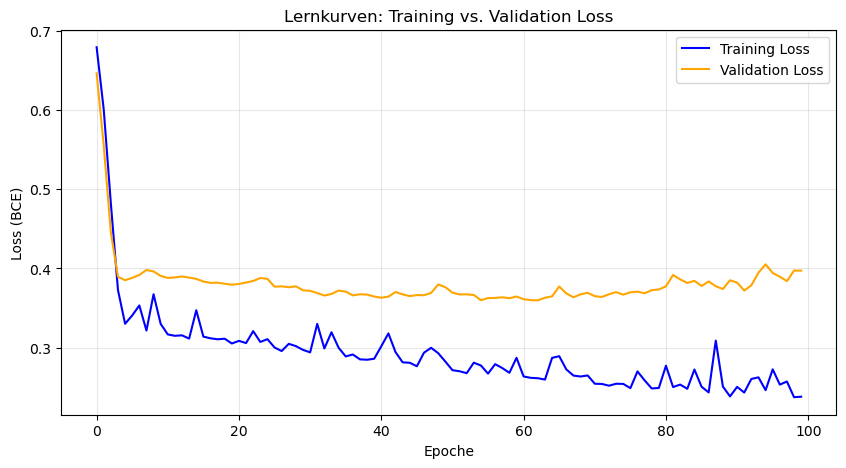

In [19]:
# Lernkurven plotten
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss', color='blue')
plt.plot(val_losses, label='Validation Loss', color='orange')
plt.xlabel('Epoche')
plt.ylabel('Loss (BCE)')
plt.title('Lernkurven: Training vs. Validation Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Verständnisfragen: Lernkurven

**Frage A:** Betrachten Sie die Lernkurven oben. Liegt Overfitting, Underfitting oder ein guter Fit vor? Begründen Sie Ihre Antwort.
> 

**Frage B:** Nennen Sie zwei Massnahmen, die man ergreifen kann, um Overfitting zu reduzieren.
>

**Frage C:** Ab welcher Epoche (ungefähr) scheint der Validation Loss nicht mehr signifikant zu sinken? Was könnte man daraus schliessen?
>

---
## 8. Modellbewertung (Metriken)

Die Loss-Funktion allein reicht nicht aus, um die Qualität eines Modells zu beurteilen. Wir berechnen nun verschiedene **Klassifikationsmetriken** auf den Testdaten:

- **Accuracy:** Anteil korrekt klassifizierter Datenpunkte.
- **Precision:** Von allen als "krank" vorhergesagten Patienten - wie viele sind tatsächlich krank?
- **Recall:** Von allen tatsächlich kranken Patienten - wie viele wurden erkannt?
- **F1-Score:** Harmonisches Mittel aus Precision und Recall.

Gerade bei medizinischen Anwendungen ist der **Recall** besonders wichtig: Es ist gefährlicher, eine Herzerkrankung zu übersehen (False Negative), als fälschlicherweise eine Herzerkrankung zu diagnostizieren (False Positive).

In [20]:
def evaluate_model(model, data_loader):
    """Berechnet Predictions fuer den gesamten DataLoader."""
    model.eval()
    all_predictions = []
    all_labels = []

    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            outputs = model(X_batch)
            predicted = (outputs >= 0.5).float()
            all_predictions.append(predicted)
            all_labels.append(y_batch)

    predictions = torch.cat(all_predictions)
    labels = torch.cat(all_labels)
    return predictions, labels


def compute_metrics(predictions, labels):
    """Berechnet Accuracy, Precision, Recall und F1-Score."""
    tp = ((predictions == 1) & (labels == 1)).sum().item()
    tn = ((predictions == 0) & (labels == 0)).sum().item()
    fp = ((predictions == 1) & (labels == 0)).sum().item()
    fn = ((predictions == 0) & (labels == 1)).sum().item()

    accuracy = (tp + tn) / (tp + tn + fp + fn)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

    return {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'TP': tp, 'TN': tn, 'FP': fp, 'FN': fn
    }

In [21]:
# Metriken auf den Testdaten berechnen
predictions, labels = evaluate_model(model, test_loader)
metrics = compute_metrics(predictions, labels)

print("=" * 40)
print("  Metriken auf den Testdaten")
print("=" * 40)
print(f"  Accuracy:  {metrics['Accuracy']:.4f}")
print(f"  Precision: {metrics['Precision']:.4f}")
print(f"  Recall:    {metrics['Recall']:.4f}")
print(f"  F1-Score:  {metrics['F1-Score']:.4f}")
print(f"\n  TP={metrics['TP']}  FP={metrics['FP']}")
print(f"  FN={metrics['FN']}  TN={metrics['TN']}")

  Metriken auf den Testdaten
  Accuracy:  0.8478
  Precision: 0.8395
  Recall:    0.8947
  F1-Score:  0.8662

  TP=68  FP=13
  FN=8  TN=49


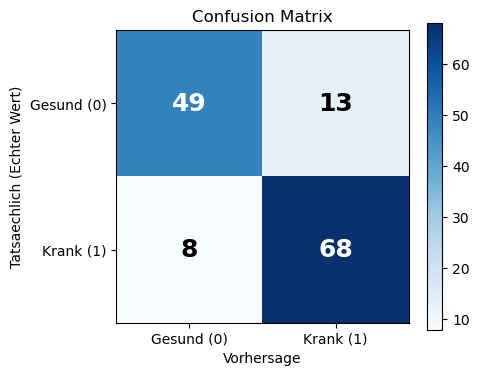

In [22]:
# Confusion Matrix visualisieren
cm = np.array([[metrics['TN'], metrics['FP']],
               [metrics['FN'], metrics['TP']]])

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap='Blues')

# Beschriftungen
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Gesund (0)', 'Krank (1)'])
ax.set_yticklabels(['Gesund (0)', 'Krank (1)'])
ax.set_xlabel('Vorhersage')
ax.set_ylabel('Tatsaechlich (Echter Wert)')
ax.set_title('Confusion Matrix')

# Werte in die Zellen schreiben
for i in range(2):
    for j in range(2):
        text_color = 'white' if cm[i, j] > cm.max() / 2 else 'black'
        ax.text(j, i, str(cm[i, j]), ha='center', va='center', 
                fontsize=18, color=text_color, fontweight='bold')

plt.colorbar(im)
plt.tight_layout()
plt.show()

Die Metriken geben uns ein detailliertes Bild der Modellleistung. Insbesondere der Recall ist bei der Erkennung von Herzerkrankungen entscheidend, da wir möglichst wenige tatsächlich kranke Personen übersehen möchten.

Im nächsten Schritt versuchen wir, die Leistung durch eine Hyperparameter-Optimierung zu verbessern.

### Verständnisfragen: Metriken

**Frage A:** Was ist der Unterschied zwischen einem False Positive und einem False Negative? Welcher ist bei der Diagnose von Herzerkrankungen schlimmer und warum?
> 

**Frage B:** Warum kann die Accuracy allein eine falsche Sicherheit vermitteln? Geben Sie ein Beispiel mit einem stark unbalancierten Dataset.
>


---
## 9. Hyperparameter-Optimierung

Hyperparameter sind Einstellungen, die **vor** dem Training festgelegt werden und nicht vom Modell selbst gelernt werden. Dazu gehören z.B. die Lernrate, die Grösse der Hidden Layers oder die Anzahl Epochen.

Wir führen eine kleine **Grid Search** durch: Wir probieren verschiedene Kombinationen von Hyperparametern aus und bewerten jeweils die Performance auf den **Validierungsdaten**. Die Testdaten verwenden wir erst ganz am Schluss für die finale Bewertung.

Wir variieren:
- **Lernrate:** 0.01, 0.001, 0.0005
- **Hidden Layer Grösse:** (32, 16) vs. (64, 32) vs. (128, 64)

In [35]:
# Hyperparameter-Kombinationen definieren
learning_rates = [0.01, 0.001, 0.0005]
hidden_sizes = [(32, 16), (64, 32), (128, 64)]

results = []

print("Starte Hyperparameter-Optimierung...")
print("=" * 70)

for lr in learning_rates:
    for h1, h2 in hidden_sizes:
        # Neues Modell erstellen
        temp_model = HeartDiseaseNet(input_size=input_size, hidden1=h1, hidden2=h2)
        
        # Training (ohne viel Output)
        criterion = nn.BCELoss()
        optimizer = torch.optim.Adam(temp_model.parameters(), lr=lr)
        
        for epoch in range(80):
            temp_model.train()
            for X_batch, y_batch in train_loader:
                optimizer.zero_grad()
                preds = temp_model(X_batch)
                loss = criterion(preds, y_batch)
                loss.backward()
                optimizer.step()
        
        # Auf Validierungsdaten auswerten
        val_preds, val_labels = evaluate_model(temp_model, val_loader)
        val_metrics = compute_metrics(val_preds, val_labels)
        
        results.append({
            'lr': lr,
            'hidden': f"({h1}, {h2})",
            'accuracy': val_metrics['Accuracy'],
            'f1': val_metrics['F1-Score'],
            'recall': val_metrics['Recall'],
            'precision': val_metrics['Precision'],
            'model': temp_model
        })
        
        print(f"LR={lr:<8} Hidden=({h1:>3},{h2:>3}) | "
              f"Val Acc: {val_metrics['Accuracy']:.4f} | "
              f"Val F1: {val_metrics['F1-Score']:.4f} | "
              f"Val Recall: {val_metrics['Recall']:.4f}"
              f" | Val Precision: {val_metrics['Precision']:.4f}")

print("=" * 70)

Starte Hyperparameter-Optimierung...
LR=0.01     Hidden=( 32, 16) | Val Acc: 0.8261 | Val F1: 0.8400 | Val Recall: 0.8289 | Val Precision: 0.8514
LR=0.01     Hidden=( 64, 32) | Val Acc: 0.8116 | Val F1: 0.8243 | Val Recall: 0.8026 | Val Precision: 0.8472
LR=0.01     Hidden=(128, 64) | Val Acc: 0.8116 | Val F1: 0.8312 | Val Recall: 0.8421 | Val Precision: 0.8205
LR=0.001    Hidden=( 32, 16) | Val Acc: 0.8406 | Val F1: 0.8590 | Val Recall: 0.8816 | Val Precision: 0.8375
LR=0.001    Hidden=( 64, 32) | Val Acc: 0.8333 | Val F1: 0.8497 | Val Recall: 0.8553 | Val Precision: 0.8442
LR=0.001    Hidden=(128, 64) | Val Acc: 0.8188 | Val F1: 0.8344 | Val Recall: 0.8289 | Val Precision: 0.8400
LR=0.0005   Hidden=( 32, 16) | Val Acc: 0.8333 | Val F1: 0.8516 | Val Recall: 0.8684 | Val Precision: 0.8354
LR=0.0005   Hidden=( 64, 32) | Val Acc: 0.8333 | Val F1: 0.8535 | Val Recall: 0.8816 | Val Precision: 0.8272
LR=0.0005   Hidden=(128, 64) | Val Acc: 0.8261 | Val F1: 0.8442 | Val Recall: 0.8553 | Val 

In [36]:
# Bestes Modell auswaehlen (nach F1-Score)
best_result = max(results, key=lambda x: x['f1'])
best_model = best_result['model']

print(f"\nBeste Hyperparameter (nach F1-Score):")
print(f"  Lernrate:      {best_result['lr']}")
print(f"  Hidden Layers: {best_result['hidden']}")
print(f"  Val Accuracy:  {best_result['accuracy']:.4f}")
print(f"  Val F1-Score:  {best_result['f1']:.4f}")
print(f"  Val Recall:    {best_result['recall']:.4f}")
print(f"  Val Precision: {best_result['precision']:.4f}")


Beste Hyperparameter (nach F1-Score):
  Lernrate:      0.001
  Hidden Layers: (32, 16)
  Val Accuracy:  0.8406
  Val F1-Score:  0.8590
  Val Recall:    0.8816
  Val Precision: 0.8375


In [37]:
# Ergebnisse als Tabelle visualisieren
results_df = pd.DataFrame([{
    'Lernrate': r['lr'],
    'Hidden Layers': r['hidden'],
    'Accuracy': round(r['accuracy'], 4),
    'F1-Score': round(r['f1'], 4),
    'Recall': round(r['recall'], 4),
    'Precision': round(r['precision'], 4)
} for r in results])

results_df.sort_values('F1-Score', ascending=False)

,Lernrate,Hidden Layers,Accuracy,F1-Score,Recall,Precision
3,0.0010,"(32, 16)",0.8406,0.8590,0.8816,0.8375
7,0.0005,"(64, 32)",0.8333,0.8535,0.8816,0.8272
6,0.0005,"(32, 16)",0.8333,0.8516,0.8684,0.8354
4,0.0010,"(64, 32)",0.8333,0.8497,0.8553,0.8442
8,0.0005,"(128, 64)",0.8261,0.8442,0.8553,0.8333
0,0.0100,"(32, 16)",0.8261,0.8400,0.8289,0.8514
5,0.0010,"(128, 64)",0.8188,0.8344,0.8289,0.8400
2,0.0100,"(128, 64)",0.8116,0.8312,0.8421,0.8205
1,0.0100,"(64, 32)",0.8116,0.8243,0.8026,0.8472


Die Hyperparameter-Optimierung ist abgeschlossen. Wir haben das beste Modell anhand des F1-Scores auf den Validierungsdaten ausgewählt. Nun bewerten wir dieses optimierte Modell auf den **Testdaten** - Daten, die das Modell noch nie gesehen hat.

### Verständnisfragen: Hyperparameter

**Frage A:** Was ist der Unterschied zwischen einem Hyperparameter und einem trainierbaren Parameter (Gewicht)?
>

**Frage B:** Warum bewerten wir die Hyperparameter-Kombinationen auf den **Validierungsdaten** und nicht auf den Testdaten?
> 

**Frage C:** Was ist ein Grid Search? Nennen Sie einen Nachteil dieses Ansatzes.
> 

---
## 10. Finale Evaluation auf den Testdaten

Wir bewerten nun das beste Modell aus der Hyperparameter-Optimierung auf den **Testdaten**. Diese Daten wurden während des gesamten Trainings und der Optimierung zurückgehalten und dienen als abschliessender, unvoreingenommener Leistungstest.

In [26]:
# Finale Evaluation mit dem besten Modell
test_preds, test_labels = evaluate_model(best_model, test_loader)
test_metrics = compute_metrics(test_preds, test_labels)

print("=" * 40)
print("  Finale Evaluation (Testdaten)")
print("=" * 40)
print(f"  Accuracy:  {test_metrics['Accuracy']:.4f}")
print(f"  Precision: {test_metrics['Precision']:.4f}")
print(f"  Recall:    {test_metrics['Recall']:.4f}")
print(f"  F1-Score:  {test_metrics['F1-Score']:.4f}")
print(f"\n  TP={test_metrics['TP']}  FP={test_metrics['FP']}")
print(f"  FN={test_metrics['FN']}  TN={test_metrics['TN']}")

  Finale Evaluation (Testdaten)
  Accuracy:  0.8696
  Precision: 0.8625
  Recall:    0.9079
  F1-Score:  0.8846

  TP=69  FP=11
  FN=7  TN=51


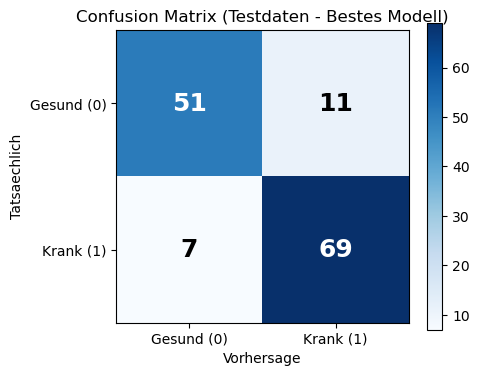

In [27]:
# Finale Confusion Matrix
cm_final = np.array([[test_metrics['TN'], test_metrics['FP']],
                     [test_metrics['FN'], test_metrics['TP']]])

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm_final, cmap='Blues')

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Gesund (0)', 'Krank (1)'])
ax.set_yticklabels(['Gesund (0)', 'Krank (1)'])
ax.set_xlabel('Vorhersage')
ax.set_ylabel('Tatsaechlich')
ax.set_title('Confusion Matrix (Testdaten - Bestes Modell)')

for i in range(2):
    for j in range(2):
        text_color = 'white' if cm_final[i, j] > cm_final.max() / 2 else 'black'
        ax.text(j, i, str(cm_final[i, j]), ha='center', va='center', 
                fontsize=18, color=text_color, fontweight='bold')

plt.colorbar(im)
plt.tight_layout()
plt.show()

Das Modell wurde nun auf den Testdaten evaluiert. Die Ergebnisse zeigen, wie gut das Modell auf komplett ungesehenen Daten abschneidet.

Im letzten Abschnitt betrachten wir, wie wir mit der **Softmax-Funktion** nicht nur eine Vorhersage, sondern auch ein **Confidencelevel** erhalten können.

---
## 11. Showcase: Softmax und Confidence-Level

Bisher hat unser Modell eine Sigmoid-Funktion verwendet, die für **binäre Klassifikation** eine Wahrscheinlichkeit zwischen 0 und 1 ausgibt. Bei **Mehrklassen-Problemen** verwendet man stattdessen die **Softmax-Funktion**, die eine Wahrscheinlichkeitsverteilung über alle Klassen liefert.

Die Softmax-Funktion ist definiert als:

$$\text{Softmax}(z_i) = \frac{e^{z_i}}{\sum_{j} e^{z_j}}$$

Sie wandelt die rohen Ausgaben des Netzwerks (Logits) in **Wahrscheinlichkeiten** um, die sich zu 1 summieren. Um dies zu demonstrieren, bauen wir eine Version unseres Modells, die den Output als Zwei-Klassen-Problem formuliert (Gesund vs. Krank) und die Softmax-Funktion nutzt, um die **Confidence** der Vorhersage auszugeben.

In [38]:
class HeartDiseaseNetSoftmax(nn.Module):
    """Version des Modells mit 2 Outputs und Softmax fuer Confidence-Analyse."""
    def __init__(self, input_size, hidden1, hidden2):
        super(HeartDiseaseNetSoftmax, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, hidden1),
            nn.ReLU(),
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Linear(hidden2, 2)  # 2 Outputs: Gesund vs. Krank
        )

    def forward(self, x):
        return self.network(x)  # Gibt Logits zurueck (keine Softmax im Forward!)


# Modell erstellen und trainieren
softmax_model = HeartDiseaseNetSoftmax(input_size=input_size, hidden1=32, hidden2=16)
criterion_ce = nn.CrossEntropyLoss()  # Erwartet Logits, wendet Softmax intern an
optimizer_sm = torch.optim.Adam(softmax_model.parameters(), lr=0.001)

# Labels muessen fuer CrossEntropyLoss als Long-Tensor vorliegen
y_train_ce = torch.tensor(y_train.values, dtype=torch.long)
y_val_ce = torch.tensor(y_val.values, dtype=torch.long)
y_test_ce = torch.tensor(y_test.values, dtype=torch.long)

train_dataset_ce = TensorDataset(X_train_tensor, y_train_ce)
train_loader_ce = DataLoader(train_dataset_ce, batch_size=32, shuffle=True)

# Training
for epoch in range(100):
    softmax_model.train()
    for X_batch, y_batch in train_loader_ce:
        optimizer_sm.zero_grad()
        logits = softmax_model(X_batch)
        loss = criterion_ce(logits, y_batch)
        loss.backward()
        optimizer_sm.step()

print("Softmax-Modell trainiert.")

Softmax-Modell trainiert.


In [39]:
# Vorhersagen mit Confidence fuer einzelne Patienten
softmax_model.eval()

# 5 zufaellige Patienten aus den Testdaten auswaehlen
np.random.seed(42)
sample_indices = np.random.choice(len(X_test_tensor), size=5, replace=False)

print("=" * 65)
print("  Vorhersagen mit Softmax-Confidence")
print("=" * 65)

klassen = ['Gesund', 'Krank']

with torch.no_grad():
    for idx in sample_indices:
        patient = X_test_tensor[idx].unsqueeze(0)
        actual = y_test_ce[idx].item()

        # Logits aus dem Netzwerk holen
        logits = softmax_model(patient)

        # Softmax anwenden um Wahrscheinlichkeiten zu erhalten
        probabilities = torch.softmax(logits, dim=1)

        predicted_class = probabilities.argmax(dim=1).item()
        confidence = probabilities[0, predicted_class].item()

        status = "KORREKT" if predicted_class == actual else "FALSCH"

        print(f"\nPatient {idx}:")
        print(f"  Logits:       [{logits[0, 0]:.3f}, {logits[0, 1]:.3f}]")
        print(f"  Softmax:      [Gesund: {probabilities[0, 0]:.1%}, Krank: {probabilities[0, 1]:.1%}]")
        print(f"  Vorhersage:   {klassen[predicted_class]} (Confidence: {confidence:.1%})")
        print(f"  Tatsaechlich: {klassen[actual]} --> {status}")

  Vorhersagen mit Softmax-Confidence

Patient 89:
  Logits:       [-1.188, 2.230]
  Softmax:      [Gesund: 3.2%, Krank: 96.8%]
  Vorhersage:   Krank (Confidence: 96.8%)
  Tatsaechlich: Krank --> KORREKT

Patient 105:
  Logits:       [0.823, -0.606]
  Softmax:      [Gesund: 80.7%, Krank: 19.3%]
  Vorhersage:   Gesund (Confidence: 80.7%)
  Tatsaechlich: Gesund --> KORREKT

Patient 12:
  Logits:       [2.537, -2.341]
  Softmax:      [Gesund: 99.2%, Krank: 0.8%]
  Vorhersage:   Gesund (Confidence: 99.2%)
  Tatsaechlich: Gesund --> KORREKT

Patient 26:
  Logits:       [-0.878, 1.912]
  Softmax:      [Gesund: 5.8%, Krank: 94.2%]
  Vorhersage:   Krank (Confidence: 94.2%)
  Tatsaechlich: Krank --> KORREKT

Patient 64:
  Logits:       [-1.100, 2.167]
  Softmax:      [Gesund: 3.7%, Krank: 96.3%]
  Vorhersage:   Krank (Confidence: 96.3%)
  Tatsaechlich: Krank --> KORREKT


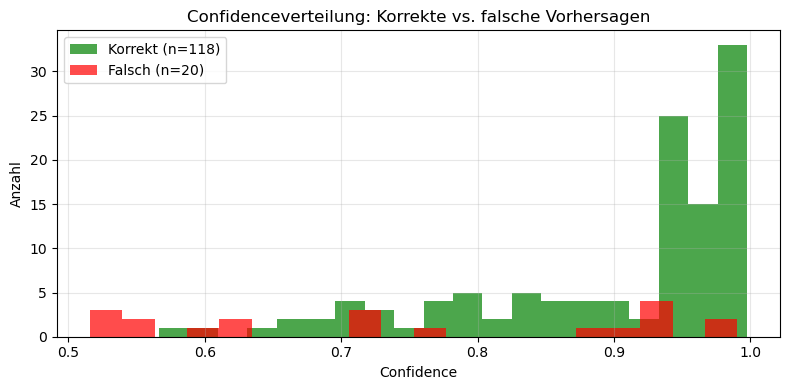

In [41]:
# Confidenceverteilung visualisieren
softmax_model.eval()
all_confidences = []
all_correct = []

with torch.no_grad():
    logits_all = softmax_model(X_test_tensor)
    probs_all = torch.softmax(logits_all, dim=1)
    predicted_all = probs_all.argmax(dim=1)
    
    for i in range(len(X_test_tensor)):
        conf = probs_all[i, predicted_all[i]].item()
        correct = (predicted_all[i].item() == y_test_ce[i].item())
        all_confidences.append(conf)
        all_correct.append(correct)

# Confidence fuer korrekte vs. falsche Vorhersagen
conf_correct = [c for c, ok in zip(all_confidences, all_correct) if ok]
conf_wrong = [c for c, ok in zip(all_confidences, all_correct) if not ok]

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(conf_correct, bins=20, alpha=0.7, label=f'Korrekt (n={len(conf_correct)})', color='green')
ax.hist(conf_wrong, bins=20, alpha=0.7, label=f'Falsch (n={len(conf_wrong)})', color='red')
ax.set_xlabel('Confidence')
ax.set_ylabel('Anzahl')
ax.set_title('Confidenceverteilung: Korrekte vs. falsche Vorhersagen')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Die Softmax-Funktion ermöglicht es uns, nicht nur eine Vorhersage zu treffen, sondern auch einzuschätzen, **wie sicher** sich das Modell ist. Im Idealfall sind korrekte Vorhersagen mit hoher Confidence und falsche Vorhersagen mit niedriger Confidence verbunden. Es ist auch zu sehen, dass es Fälle gibt, in denen das Modell falsche Vorhersagen mit hoher Confidence trifft. Dies ist besonders problematisch, da es zu falschem Vertrauen in die Vorhersagen führen kann.

### Verständnisfragen: Softmax und Confidence

**Frage A:** Was ist der Unterschied zwischen der Sigmoid- und der Softmax-Funktion? Wann verwenden wir welche?
> 

**Frage B:** Bedeutet eine hohe Confidence (z.B. 98%), dass die Vorhersage sicher korrekt ist? Warum oder warum nicht?
> 


---
## Key-Takeaways

In diesem Notebook haben wir die gesamte Machine Learning Pipeline durchlaufen:

1. **Datenbeschaffung:** Laden des Heart Disease Datasets.
2. **Datenqualität:** Prüfung auf fehlende Werte, unrealistische Einträge (Cholesterin/Blutdruck = 0) und Ausreisser.
3. **Datenvorverarbeitung:** Ordinal- und One-Hot-Encoding für kategoriale Variablen; Min-Max-Normalisierung für numerische Features.
4. **Datenaufteilung:** Train (70%) / Validation (15%) / Test (15%) mit stratified Split für ausgewogene Klassenverteilung.
5. **Modellarchitektur:** Kleines neuronales Netzwerk mit zwei Hidden Layers (ReLU) und Sigmoid-Output.
6. **Training:** Trainingsschleife mit BCELoss und Adam-Optimizer; Überwachung des Validation Loss.
7. **Lernkurven:** Analyse von Overfitting/Underfitting durch Vergleich von Training und Validation Loss.
8. **Metriken:** Evaluation mit Accuracy, Precision, Recall, F1-Score und Confusion Matrix auf den Testdaten.
9. **Hyperparameter-Optimierung:** Grid Search über Lernrate und Netzwerkgrösse. Ergebnisse werden auf den Validierungsdaten bewertet, um das beste Modell auszuwählen. Die Testdaten werden erst ganz am Schluss für die finale Bewertung verwendet.
10. **Softmax-Showcase:** Confidence-Analyse mit der Softmax-Funktion für interpretierbare Vorhersagen.